In [1]:
# Load the saved model datasets
import pandas as pd
from pathlib import Path

MODEL_DATA_PATH = Path("../model_datasets")

X_train = pd.read_parquet(MODEL_DATA_PATH / "X_train_scaled.parquet")
X_val   = pd.read_parquet(MODEL_DATA_PATH / "X_val_scaled.parquet")
X_test  = pd.read_parquet(MODEL_DATA_PATH / "X_test_scaled.parquet")

y_train = pd.read_parquet(MODEL_DATA_PATH / "y_train.parquet")["optimal_bucket_encoded"]
y_val   = pd.read_parquet(MODEL_DATA_PATH / "y_val.parquet")["optimal_bucket_encoded"]
y_test  = pd.read_parquet(MODEL_DATA_PATH / "y_test.parquet")["optimal_bucket_encoded"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (28949, 53) y_train: (28949,)
X_val: (5010, 53) y_val: (5010,)
X_test: (5020, 53) y_test: (5020,)


In [2]:
print("Train class distribution:")
print(y_train.value_counts().sort_index())

num_classes = y_train.nunique()
print("Number of classes:", num_classes)

Train class distribution:
optimal_bucket_encoded
0    5883
1    2081
2    9762
3    2905
4     318
5    2253
6    1783
7    2455
8    1509
Name: count, dtype: int64
Number of classes: 9


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=500,
    max_depth=3,
    learning_rate=0.002,
    min_child_weight=10,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1.0,
    reg_alpha=2.0,
    reg_lambda=5.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'mlogloss'


In [15]:
results = xgb_model.evals_result()

In [16]:
print(results.keys())

dict_keys(['validation_0', 'validation_1'])


In [17]:
train_loss = results["validation_0"]["mlogloss"]
val_loss = results["validation_1"]["mlogloss"]

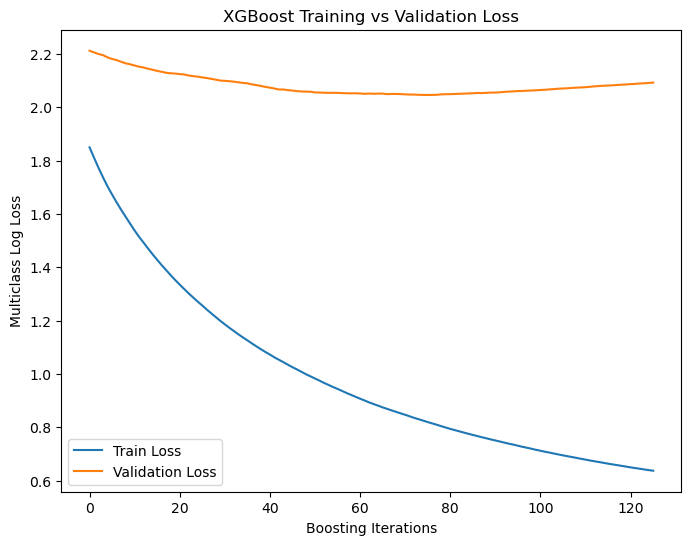

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Boosting Iterations")
plt.ylabel("Multiclass Log Loss")
plt.title("XGBoost Training vs Validation Loss")
plt.legend()

plt.show()

In [19]:
y_train_pred = xgb_model.predict(X_train)
y_val_pred   = xgb_model.predict(X_val)
y_test_pred  = xgb_model.predict(X_test)

In [20]:
# Evaluate model performance

from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTest Classification Report")
print(classification_report(y_test, y_test_pred))

Train Accuracy: 0.8092852948288369
Val Accuracy: 0.28283433133732533
Test Accuracy: 0.1254980079681275

Test Classification Report
              precision    recall  f1-score   support

           0       0.12      0.01      0.02       669
           1       0.00      0.00      0.00       214
           2       0.15      0.82      0.25       706
           3       0.04      0.09      0.06       247
           4       0.00      0.00      0.00       390
           5       0.00      0.00      0.00      1872
           6       0.00      0.00      0.00       210
           7       0.04      0.16      0.06       123
           8       0.00      0.00      0.00       589

    accuracy                           0.13      5020
   macro avg       0.04      0.12      0.04      5020
weighted avg       0.04      0.13      0.04      5020



/opt/anaconda3/envs/covered_call_ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/covered_call_ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/covered_call_ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

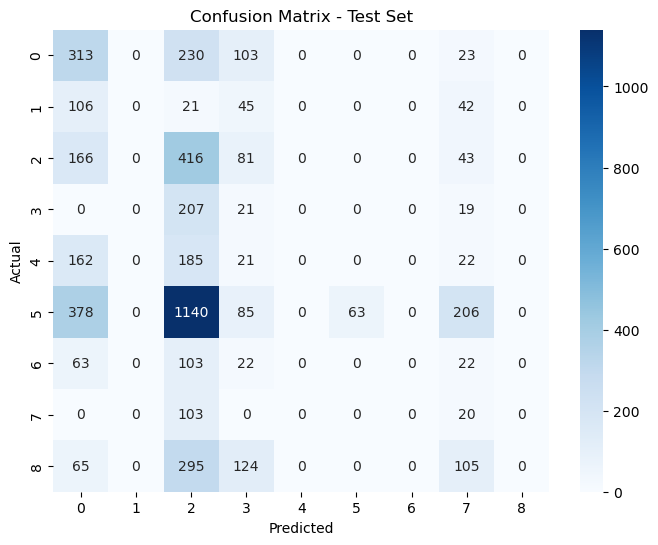

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [12]:
import pandas as pd

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(20))

200DayMovingAverage             0.159594
symbol_AXON                     0.116611
52WeekLow                       0.092724
PERatio                         0.077583
Beta                            0.074372
SharesOutstanding               0.031673
commonStockSharesOutstanding    0.025931
totalRevenue                    0.024014
high                            0.023098
book_value_per_share_proxy      0.022745
rolling_max                     0.021057
EPS                             0.020185
totalLiabilities                0.019642
symbol_AAPL                     0.018432
operatingExpenses               0.017362
BookValue                       0.017358
longTermDebt                    0.017297
dividendPayout                  0.015218
grossProfit                     0.014088
totalShareholderEquity          0.013604
dtype: float32


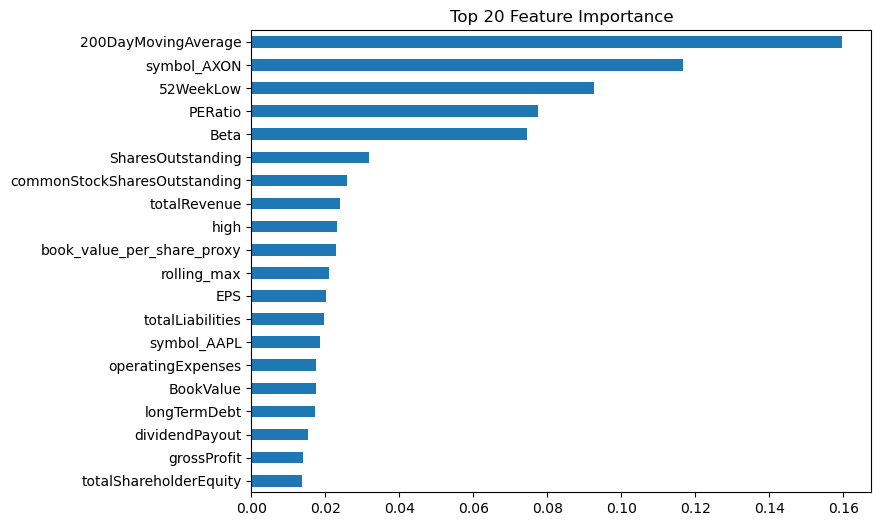

In [13]:
importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(8,6),
    title="Top 20 Feature Importance"
)

plt.show()